In [1]:
import numpy as np
from IPython.core.pylabtools import figsize
from matplotlib import pyplot as plt
import pandas as pd

# Data

## Data exploration

The worksheet suggests us to download the complete dataset from the NASA Exoplanet archive, however, we find it more convinient to sort dataset on the website. Only two filters are applied: both mass and radius are greater than zero (this is equivalent to NaN filtering in pandas).

In [2]:
df = pd.read_csv('Planets_dataset.csv', header=27)

[]

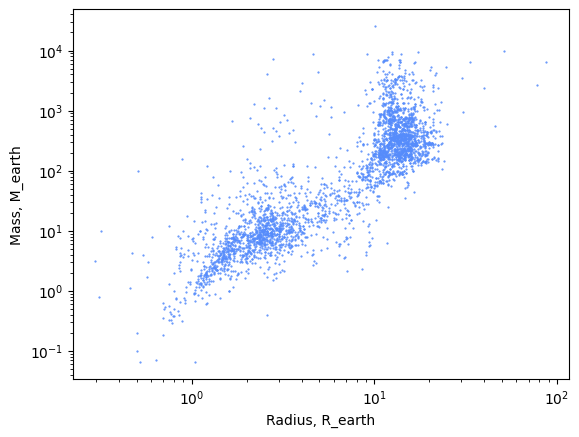

In [3]:
plt.scatter(df['pl_rade'], df['pl_masse'], s=0.3)
plt.xlabel('Radius, R_earth')
plt.ylabel('Mass, M_earth')
plt.loglog()

To get the sample A from the task, we calculate simmetrical errors and drop rows where errors are unknown.

In [4]:
sample_a = df[['pl_rade', 'pl_masse', 'st_mass']].copy()
sample_a['pl_masseerr'] = (df['pl_masseerr1'] - df['pl_masseerr2'])/2.
sample_a.dropna(inplace=True, ignore_index=True)

[]

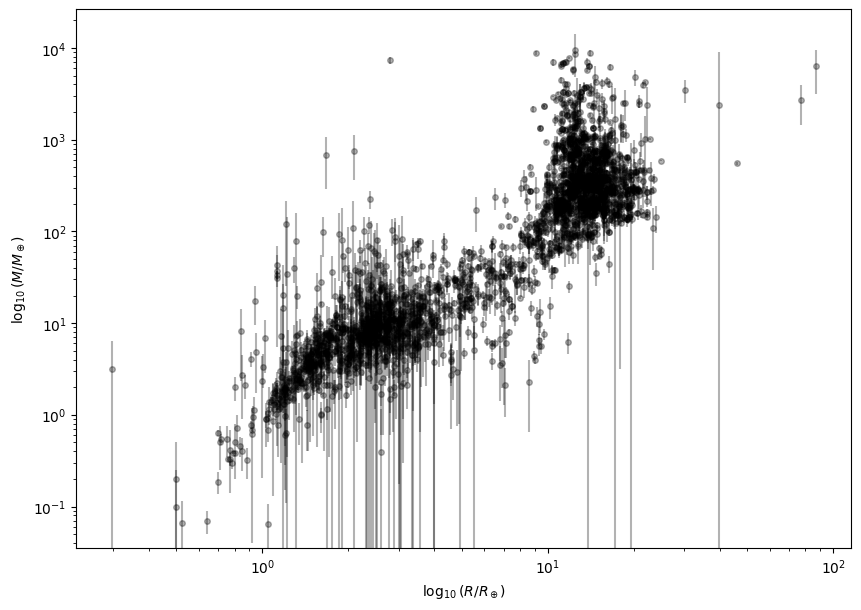

In [123]:
# plt.scatter(df['pl_rade'], df['pl_masse'], s=0.3)
fig, ax = plt.subplots(figsize=(10, 7))
ax.errorbar(sample_a['pl_rade'], sample_a['pl_masse'], yerr=sample_a['pl_masseerr'], ls='None', marker='o', c='black', alpha=0.3, markersize=4)
ax.set_xlabel(r'$\log_{10}(R/R_\oplus)$')
ax.set_ylabel(r'$\log_{10}(M/M_\oplus)$')
ax.loglog()

In [6]:
sample_b = sample_a[sample_a['pl_rade'] <= 5].copy()

[]

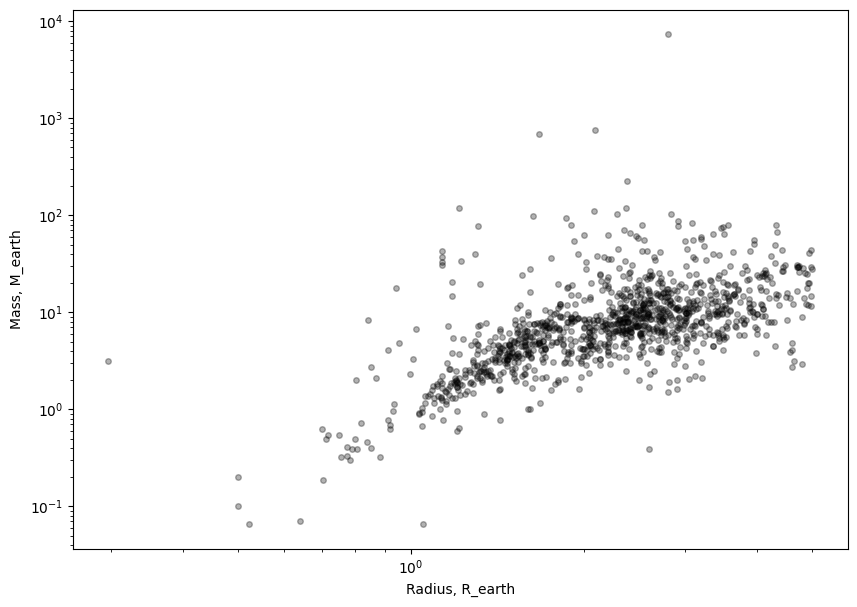

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.errorbar(sample_b['pl_rade'], sample_b['pl_masse'], ls='None', marker='o', c='black', alpha=0.3, markersize=4)
ax.set_xlabel('Radius, R_earth')
ax.set_ylabel('Mass, M_earth')
ax.loglog()

# Regression

## Linear regression

In [8]:
N = len(sample_b)
X = np.log10(sample_b['pl_rade'].values.reshape((N, 1)))
y = np.log10(sample_b['pl_masse'].values.reshape((N, 1)))

In [ ]:
# theta_ml = np.linalg.pinv(X) @ y
theta_ml = np.linalg.inv(X.T @ X) @ X.T @ y
print(theta_ml)

In [135]:
X_theor = np.linspace(X.min()*0.8, X.max()*1.5, 100).reshape((-1,1))

In [136]:
y_theor = X_theor @ theta_ml

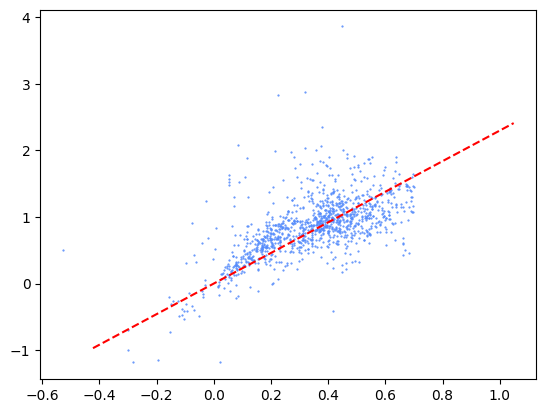

In [137]:
plt.scatter(X.flatten(), y.flatten(), s=0.3)
plt.plot(X_theor.flatten(), y_theor.flatten(), 'r--')

In [138]:
def neg_log_likelihood(y_obs, y_theor, sigma=1):
    return 0.5*np.sum(((y_obs - y_theor) / sigma)**2)

In [139]:
neg_log_likelihood(y, y_theor)

ValueError: operands could not be broadcast together with shapes (1145,1) (100,1) 

In [14]:
# thetas = np.linspace(theta_ml/2, theta_ml*2, 100)
#
# neg_log_likelihoods = np.array([neg_log_likelihood(X, y, theta) for theta in thetas])
# plt.plot(thetas.flatten(), neg_log_likelihoods.flatten())

In [15]:
Phi = np.ones((N, 1))
Phi = np.concatenate((Phi, X), axis=1)

In [16]:
theta_ml_int = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y
print(theta_ml_int)

[[0.32619195]
 [1.55177146]]


In [140]:
Phi_theor = np.ones((100, 1))
Phi_theor = np.concatenate((Phi_theor, X_theor), axis=1)

In [141]:
y_theor2 = Phi_theor @ theta_ml_int

Text(0, 0.5, '$\\log_{10}(M/M_\\oplus)$')

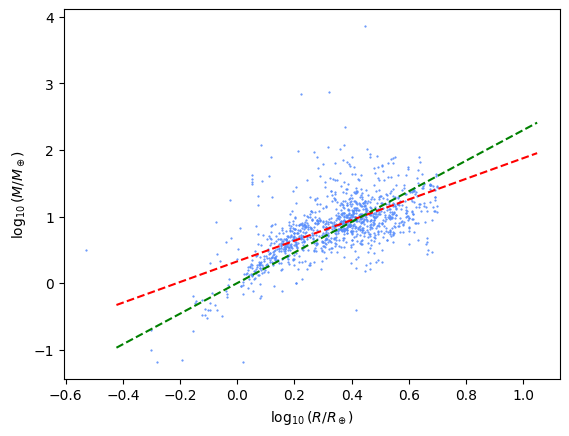

In [146]:
plt.scatter(X.flatten(), y.flatten(), s=0.3)
plt.plot(X_theor.flatten(), y_theor2.flatten(), 'r--')
plt.plot(X_theor.flatten(), y_theor.flatten(), 'g--')

In [19]:
neg_log_likelihood(y, y_theor2)

np.float64(73.37569711816442)

In [95]:
ss_planets = pd.read_csv('Solar_system.csv', usecols=[0, 2, 3], skiprows=2,
                         names=['name', 'radius', 'mass'])

In [96]:
ss_planets['mass_err'] = ss_planets.apply(lambda x: float(x['mass'].split('±')[-1]), axis=1)
ss_planets['radius_err'] = ss_planets.apply(lambda x: float(x['radius'].split('±')[-1]), axis=1)
ss_planets['mass'] = ss_planets.apply(lambda x: float(x['mass'].split()[0]), axis=1)
ss_planets['radius'] = ss_planets.apply(lambda x: float(x['radius'].split()[0]), axis=1)

In [97]:
ss_planets['mass_err'] = ss_planets['mass_err']/ss_planets.loc[2]['mass']
ss_planets['mass'] = ss_planets['mass']/ss_planets.loc[2]['mass']
ss_planets['radius_err'] = ss_planets['radius_err']/ss_planets.loc[2]['radius']
ss_planets['radius'] = ss_planets['radius']/ss_planets.loc[2]['radius']

Text(0, 0.5, '$\\log_{10}(M/M_\\oplus)$')

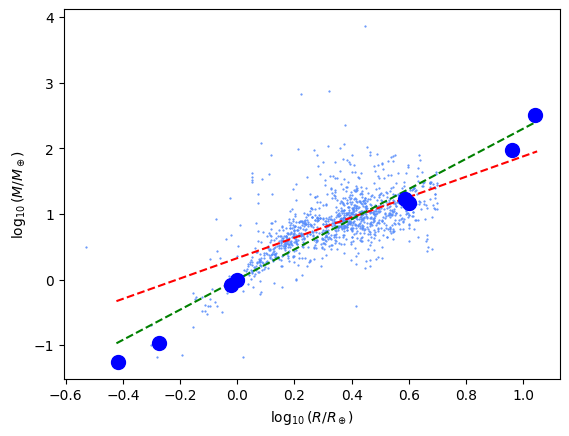

In [147]:
plt.scatter(X.flatten(), y.flatten(), s=0.3)
plt.plot(X_theor.flatten(), y_theor2.flatten(), 'r--')
plt.plot(X_theor.flatten(), y_theor.flatten(), 'g--')
plt.plot(np.log10(ss_planets['radius']), np.log10(ss_planets['mass']), 'o', ms=10, color='blue')

plt.xlabel(r'$\log_{10}(R/R_\oplus)$')
plt.ylabel(r'$\log_{10}(M/M_\oplus)$')

In [24]:
def log_errs(val, errs):
    upper = np.log10(val+errs)
    mask = (val - errs <= 0)
    lower = np.log10(val-errs)
    lower[mask] = -np.inf
    logerr = 0.5*(upper-lower)
    return logerr

In [25]:
y_lin = sample_b['pl_masse'].values.reshape((N, 1))
y_lin_err = sample_b['pl_masseerr'].values.reshape((N, 1))
y_err = log_errs(y_lin, y_lin_err)
mask = ~np.isinf(y_err)

/tmp/ipykernel_261513/1088956842.py:4: RuntimeWarning: divide by zero encountered in log10
  lower = np.log10(val-errs)
/tmp/ipykernel_261513/1088956842.py:4: RuntimeWarning: invalid value encountered in log10
  lower = np.log10(val-errs)


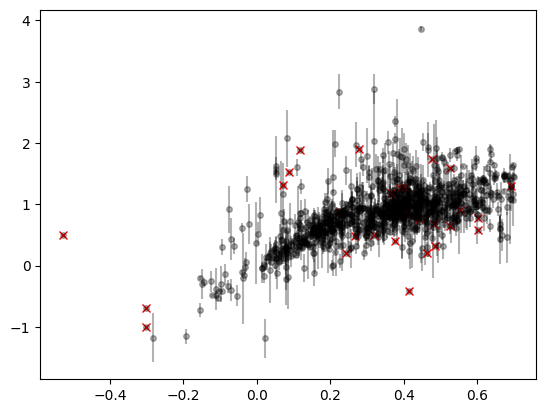

In [40]:
plt.figure()
plt.errorbar(X.flatten(), y.flatten(), yerr=y_err.flatten(), ls='None', marker='o', c='black', alpha=0.3, markersize=4)
plt.plot(X[~mask], y[~mask], ms=6, c='red', marker='x', ls='')

In [27]:
N_masked = np.sum(mask)

# m for 'masked'
X_m = X[mask].reshape((-1,1))
y_m = y[mask].reshape((-1,1))
y_err_m = y_err[mask].reshape((-1,1))

In [28]:
C_inv = np.linalg.inv(np.eye(N_masked) * y_err_m)

In [29]:
theta_ml_err = np.linalg.inv(X_m.T @ C_inv @ X_m) @ X_m.T @ C_inv @ y_m
print(theta_ml_err)

[[2.33307538]]


In [148]:
y_theor_m = X_theor @ theta_ml_err

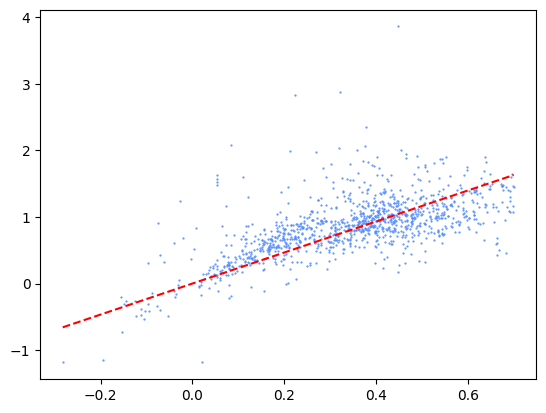

In [31]:
plt.scatter(X_m.flatten(), y_m.flatten(), s=0.3)
plt.plot(X_m.flatten(), y_theor_m.flatten(), 'r--')

[[0.23961291]
 [1.78877586]]


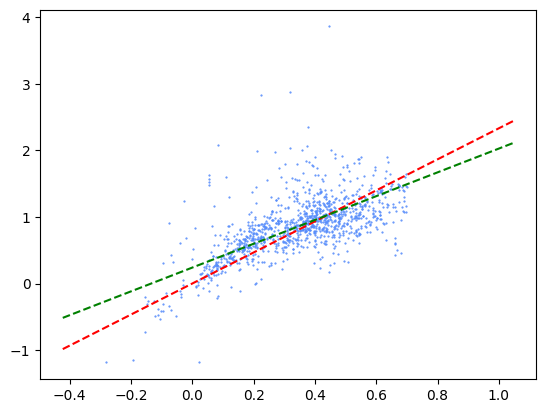

In [149]:
Phi_m = np.ones((N_masked, 1))
Phi_m = np.concatenate((Phi_m, X_m), axis=1)
theta_ml_int_err = np.linalg.inv(Phi_m.T @ C_inv @ Phi_m) @ Phi_m.T @ C_inv @ y_m
print(theta_ml_int_err)
y_theor2_m = Phi_theor @ theta_ml_int_err
plt.scatter(X_m.flatten(), y_m.flatten(), s=0.3)
plt.plot(X_theor.flatten(), y_theor_m.flatten(), 'r--')
plt.plot(X_theor.flatten(), y_theor2_m.flatten(), 'g--')


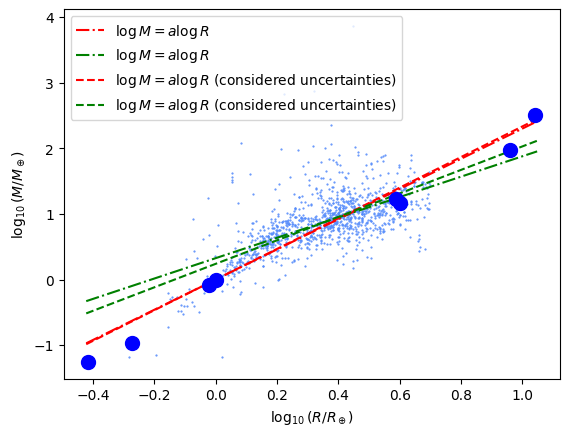

In [158]:
plt.scatter(X_m.flatten(), y_m.flatten(), s=0.3)
plt.plot(X_theor.flatten(), y_theor.flatten(), 'r-.', label=r'$\log M = a \log R$')
plt.plot(X_theor.flatten(), y_theor2.flatten(), 'g-.', label=r'$\log M = a \log R$')
plt.plot(X_theor.flatten(), y_theor_m.flatten(), 'r--', label=r'$\log M = a \log R$ (considered uncertainties)')
plt.plot(X_theor.flatten(), y_theor2_m.flatten(), 'g--', label=r'$\log M = a \log R$ (considered uncertainties)')
plt.plot(np.log10(ss_planets['radius']), np.log10(ss_planets['mass']), 'o', ms=10, color='blue')


plt.xlabel(r'$\log_{10}(R/R_\oplus)$')
plt.ylabel(r'$\log_{10}(M/M_\oplus)$')
plt.legend()
# plt.xlim(-0.5, 1)

## Polynomial regression

In [64]:
def polymatrix(X, p):
    phi = np.ones((len(X), 1))
    for i in range(1,p+1):
        phi = np.concatenate((phi, X**i), axis=1)
    return phi

In [65]:
N_a = len(sample_a)
y_poly = np.log10(sample_a['pl_masse'].values.reshape((N_a, 1)))
X_poly = np.log10(sample_a['pl_rade'].values.reshape((N_a, 1)))

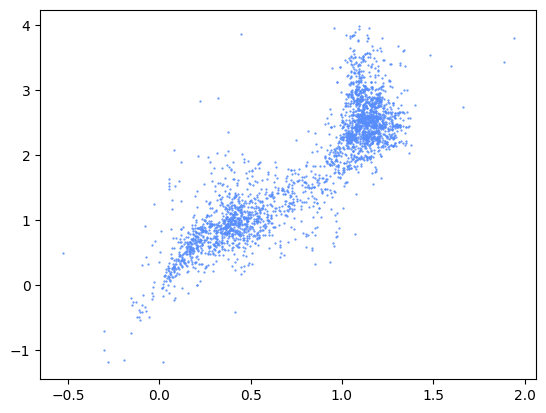

In [66]:
plt.scatter(X_poly, y_poly, s=0.3)

In [67]:
y_poly_lin = sample_a['pl_masse'].values.reshape((N_a, 1))
y_poly_lin_err = sample_a['pl_masseerr'].values.reshape((N_a, 1))
y_poly_err = log_errs(y_poly_lin, y_poly_lin_err)
mask_p = ~np.isinf(y_poly_err)

/tmp/ipykernel_261513/1088956842.py:4: RuntimeWarning: divide by zero encountered in log10
  lower = np.log10(val-errs)
/tmp/ipykernel_261513/1088956842.py:4: RuntimeWarning: invalid value encountered in log10
  lower = np.log10(val-errs)


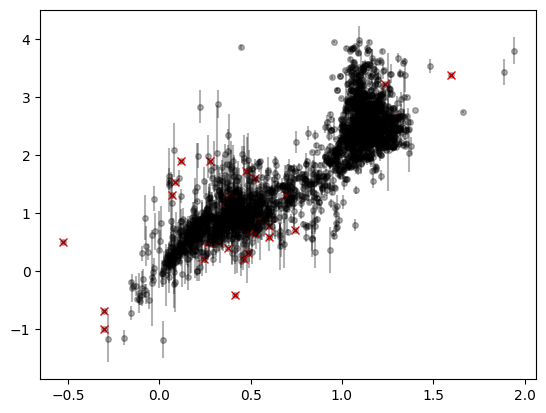

In [68]:
plt.figure()
plt.errorbar(X_poly.flatten(), y_poly.flatten(), yerr=y_poly_err.flatten(), ls='None', marker='o', c='black', alpha=0.3, markersize=4)
plt.plot(X_poly[~mask_p], y_poly[~mask_p], ms=6, c='red', marker='x', ls='')

In [69]:
N_a_m = np.sum(mask_p)

X_p = X_poly[mask_p].reshape((-1,1))
y_p = y_poly[mask_p].reshape((-1,1))
y_p_err = y_poly_err[mask_p].reshape((-1,1))

In [70]:
C_inv_p = np.linalg.inv(np.eye(N_a_m) * y_p_err)


0
[[2.22903283]]
1062.4226901209458
2140.775776823116

1
[[0.15929403]
 [2.17893506]]
466.8896219325234
965.6400370274955

2
[[-0.05353669]
 [ 3.06043474]
 [-0.61525846]]
428.51805107490617
904.8272918934854

3
[[ 0.27065367]
 [ 0.54198569]
 [ 3.5836931 ]
 [-1.94903156]]
370.13469503232795
803.9909763895533

4
[[ 0.20648149]
 [ 1.73955314]
 [-0.38624619]
 [ 2.30811738]
 [-1.44386661]]
376.70555176619644
833.0630864385146

5
[[  0.22491729]
 [  4.94713744]
 [-19.26830688]
 [ 36.95247869]
 [-26.84904394]
 [  6.47061627]]
325.9660876435958
747.5145547745377


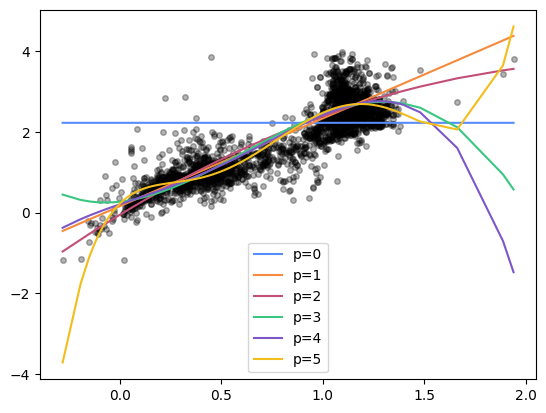

In [84]:
chi2_arr = []
BICs = []
thetas = []

plt.plot(X_p, y_p, ms=4, c='black', marker='o', ls='', alpha=0.3)
for i in range(6):
    phi = polymatrix(X_p, i)
    theta_p = np.linalg.inv(phi.T @ C_inv_p @ phi) @ phi.T @ C_inv_p @ y_p
    print()
    print(i)
    print(theta_p)
    y_t = phi @ theta_p
    chi2 = neg_log_likelihood(y_p, y_t, y_p_err)/len(y_p)
    BIC = 2*chi2 + 2*(i+1)*np.log(len(y_p))
    print(chi2)
    print(BIC)
    chi2_arr.append(chi2)
    BICs.append(BIC)
    thetas.append(theta_p)
    plt.plot(X_p, y_t, ls='-', label=f'p={i}')

plt.legend()

Text(0, 0.5, 'Chi2 improvement')

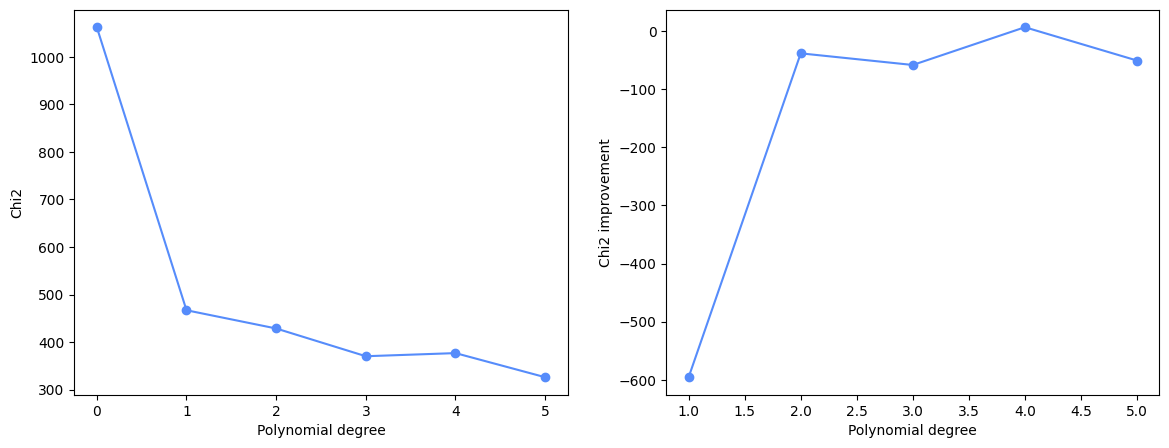

In [75]:
pol_pow = np.arange(6)
fix, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(pol_pow, chi2_arr, 'o-')
ax[0].set_xlabel('Polynomial degree')
ax[0].set_ylabel('Chi2')

ax[1].plot(pol_pow[1:], np.diff(chi2_arr), 'o-')
ax[1].set_xlabel('Polynomial degree')
ax[1].set_ylabel('Chi2 improvement')

BIC improvements  [-1175.1357398    -60.81274513  -100.8363155     29.07211005
   -85.54853166]


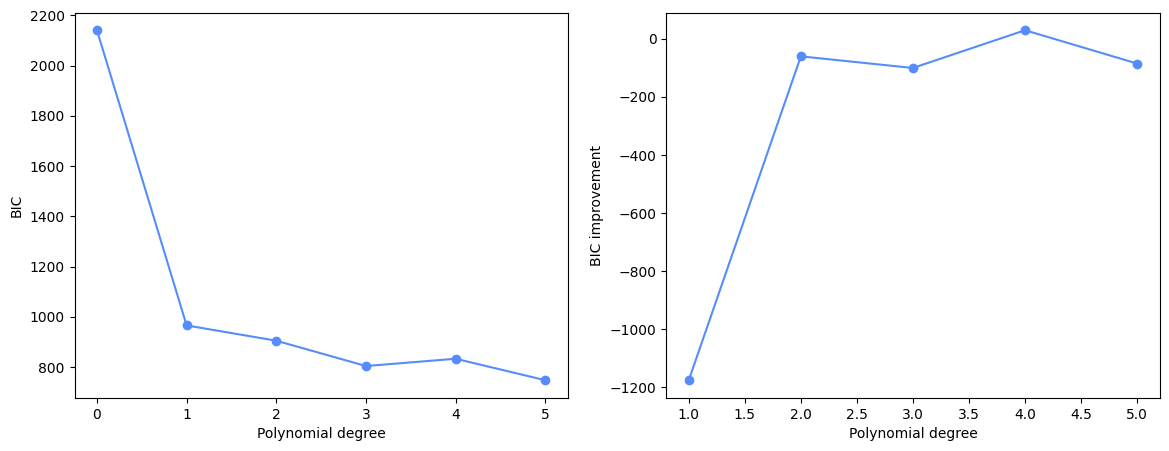

In [81]:
pol_pow = np.arange(6)
fix, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(pol_pow, BICs, 'o-')
ax[0].set_xlabel('Polynomial degree')
ax[0].set_ylabel('BIC')

ax[1].plot(pol_pow[1:], np.diff(BICs), 'o-')
ax[1].set_xlabel('Polynomial degree')
ax[1].set_ylabel('BIC improvement')

print("BIC improvements ", np.diff(BICs))

In [99]:
ss_radius_log = np.log10(ss_planets['radius'].values.reshape((-1, 1)))

for pow_test in range(6):
    phi_ss = polymatrix(ss_radius_log, pow_test)
    ss_mass_pred = phi_ss @ thetas[pow_test]
    ss_planets[f'mass_pred (p={pow_test})'] = 10**ss_mass_pred




In [100]:
ss_planets[['name', 'mass', 'mass_pred (p=0)', 'mass_pred (p=1)', 'mass_pred (p=2)', 'mass_pred (p=3)', 'mass_pred (p=4)', 'mass_pred (p=5)']]

,name,mass,mass_pred (p=0),mass_pred (p=1),mass_pred (p=2),mass_pred (p=3),mass_pred (p=4),mass_pred (p=5)
0,Mercury,0.0552735437872666,169.44659052921912,0.17817270827227402,0.03660520028383157,6.439896349481604,0.15965234647006135,1.746486368371286e-09
1,Venus,0.8149985683595744,169.44659052921912,1.290186011503864,0.7548084299285546,1.8212190500082461,1.4703809497305682,1.2719185243315125
2,Earth,1.0,169.44659052921912,1.443092025739829,0.8840224733920037,1.864891926289975,1.6087238251058005,1.6784843397447051
3,Mars,0.10744687441918097,169.44659052921912,0.36484446427075984,0.11520374010402233,2.7003939786798172,0.44161125745156293,0.0003158230152796858
4,Jupiter,317.8283605456643,169.44659052921912,266.76050187677095,291.3751529139228,330.07262005222236,320.4067988332846,362.55533098107634
5,Saturn,95.1608879184618,169.44659052921912,179.12217886626775,208.56897995327378,235.09897295693577,217.9626382717669,242.0822015117555
6,Uranus,14.535738265990418,169.44659052921912,29.282037269754056,36.406069820531705,29.168642818530444,26.45640111565044,18.272431855746106
7,Neptune,17.147736919746087,169.44659052921912,27.452367940293144,33.97885446206526,26.898537543984354,24.55932323386564,16.874960191298324


In [101]:
## 2D linear fit

In [108]:
y_2D_lin = sample_a['pl_masse'].values.reshape((N_a, 1))
y_2D_lin_err = sample_a['pl_masseerr'].values.reshape((N_a, 1))
y_2D_err = log_errs(y_2D_lin, y_2D_lin_err)
mask_2D = ~np.isinf(y_2D_err)

N_2D = np.sum(mask_2D)
Z = np.log10(sample_a['st_mass'].values.reshape((N_a, 1)))
X_full = np.log10(sample_a['pl_rade'].values.reshape((N_a, 1)))
y_full = np.log10(sample_a['pl_masse'].values.reshape((N_a, 1)))

X_2D = X_full[mask_2D].reshape((-1, 1))
y_2D = y_full[mask_2D].reshape((-1, 1))
y_2D_err = y_2D_err[mask_2D].reshape((-1, 1))
Z_2D = Z[mask_2D].reshape((-1, 1))

/tmp/ipykernel_261513/1088956842.py:4: RuntimeWarning: divide by zero encountered in log10
  lower = np.log10(val-errs)
/tmp/ipykernel_261513/1088956842.py:4: RuntimeWarning: invalid value encountered in log10
  lower = np.log10(val-errs)


In [109]:

C_inv_2D = np.linalg.inv(np.eye(N_2D) * y_2D_err)

In [110]:
phi2D = np.ones_like(X_2D)
phi2D = np.concatenate((phi2D, X_2D, Z_2D), axis=1)

In [114]:
theta_2D = np.linalg.inv(phi2D.T @ C_inv_2D @ phi2D) @ phi2D.T @ C_inv_2D @ y_2D
print(theta_2D)

[[0.24368456]
 [2.09475789]
 [0.27915391]]


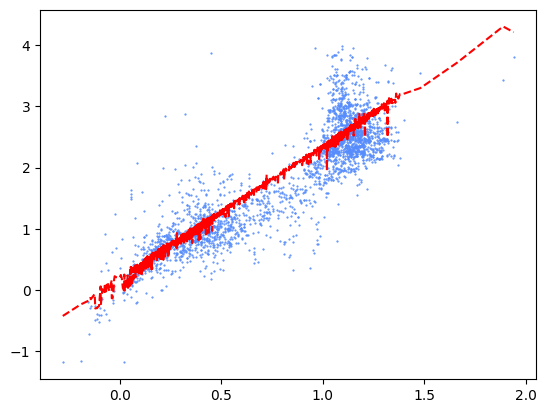

In [116]:
y_theor_2D = phi2D @ theta_2D
plt.scatter(X_2D.flatten(), y_2D.flatten(), s=0.3)
plt.plot(X_2D.flatten(), y_theor_2D.flatten(), 'r--')


In [117]:
phi_mock_2d = np.ones_like(ss_radius_log)
mass_sun_mock = np.zeros_like(ss_radius_log)
phi_mock_2d = np.concatenate((phi_mock_2d, ss_radius_log, mass_sun_mock), axis=1)

In [118]:
mass_pred_2d = phi_mock_2d @ theta_2D

In [121]:
ss_planets['mass_pred (2D_linear)'] = 10**mass_pred_2d

In [122]:
ss_planets[['name', 'mass', 'mass_pred (p=1)', 'mass_pred (p=2)', 'mass_pred (p=3)', 'mass_pred (2D_linear)']]

,name,mass,mass_pred (p=1),mass_pred (p=2),mass_pred (p=3),mass_pred (2D_linear)
0,Mercury,0.0552735437872666,0.17817270827227402,0.03660520028383157,6.439896349481604,0.23459961489494435
1,Venus,0.8149985683595744,1.290186011503864,0.7548084299285546,1.8212190500082461,1.573700205972545
2,Earth,1.0,1.443092025739829,0.8840224733920037,1.864891926289975,1.7526070782511525
3,Mars,0.10744687441918097,0.36484446427075984,0.11520374010402233,2.7003939786798172,0.4672711261824403
4,Jupiter,317.8283605456643,266.76050187677095,291.3751529139228,330.07262005222236,264.8130661799069
5,Saturn,95.1608879184618,179.12217886626775,208.56897995327378,235.09897295693577,180.5716438051173
6,Uranus,14.535738265990418,29.282037269754056,36.406069820531705,29.168642818530444,31.658300740156
7,Neptune,17.147736919746087,27.452367940293144,33.97885446206526,26.898537543984354,29.75422584703332
